# 03 — Инженерия признаков заголовка

Запускаем сквозной пайплайн построения фич (`src/features/build_dataset.py`), смотрим на распределения, корреляции с таргетом и мультиколлинеарность новых признаков.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

from src.config import BINARY_TARGET_COL, FEATURES_PARQUET_PATH, REPORT_IMAGES_DIR, TARGET_COL
from src.features.build_dataset import build_dataset
from src.features.title_features import TITLE_FEATURE_COLUMNS
from src.utils.seed import set_global_seed

set_global_seed()
sns.set_theme(style='whitegrid')

In [2]:
if not FEATURES_PARQUET_PATH.exists():
    build_dataset()
df = pd.read_parquet(FEATURES_PARQUET_PATH)
print(f'Shape: {df.shape}')
df[['url', 'title', TARGET_COL, BINARY_TARGET_COL]].head(3)

Shape: (39643, 50)


,url,title,shares,is_popular
0,http://mashable.com/2013/01/07/amazon-instant-...,Amazon Instant Video Browser,593,0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,Ap Samsung Sponsored Tweets,711,0
2,http://mashable.com/2013/01/07/apple-40-billio...,Apple 40 Billion App Downloads,1500,1


In [3]:
tf_cols = [c for c in TITLE_FEATURE_COLUMNS if c in df.columns]
df[tf_cols].describe().T.round(3).head(10)

,count,mean,std,min,25%,50%,75%,max
tf_title_char_len,39643.0,25.585,10.274,2.0,19.0,24.000,30.000,160.0
tf_title_word_len,39643.0,3.932,1.689,1.0,3.0,4.000,5.000,24.0
tf_avg_word_len,39643.0,5.836,1.343,1.5,5.0,5.667,6.667,15.0
tf_has_question,39643.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0
tf_has_exclamation,39643.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0
tf_has_number,39643.0,0.134,0.341,0.0,0.0,0.000,0.000,1.0
tf_digit_ratio,39643.0,0.013,0.041,0.0,0.0,0.000,0.000,0.7
tf_punct_ratio,39643.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0
tf_capitalized_ratio,39643.0,0.996,0.037,0.0,1.0,1.000,1.000,1.0
tf_all_caps_ratio,39643.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0


In [4]:
y = df[BINARY_TARGET_COL].to_numpy()
log_shares = np.log1p(df[TARGET_COL])
corrs = pd.DataFrame({
    'corr_log_shares': [df[c].corr(log_shares) for c in tf_cols],
    'corr_is_popular': [df[c].corr(df[BINARY_TARGET_COL]) for c in tf_cols],
}, index=tf_cols).sort_values('corr_is_popular', key=np.abs, ascending=False)
corrs.head(15).round(4)

C:\Users\HONOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\HONOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,corr_log_shares,corr_is_popular
tf_title_word_len,-0.0129,-0.0213
tf_title_char_len,-0.0135,-0.0209
tf_noun_ratio,-0.0188,-0.0185
tf_surprise_count,-0.0158,-0.0141
tf_verb_ratio,0.0093,0.0137
tf_clickbait_word_count,0.0098,0.0118
tf_adj_ratio,0.0090,0.0107
tf_stopwords_ratio,0.0145,0.0081
tf_clickbait_phrase_count,-0.0013,-0.0064
tf_vader_pos,0.0080,0.0059


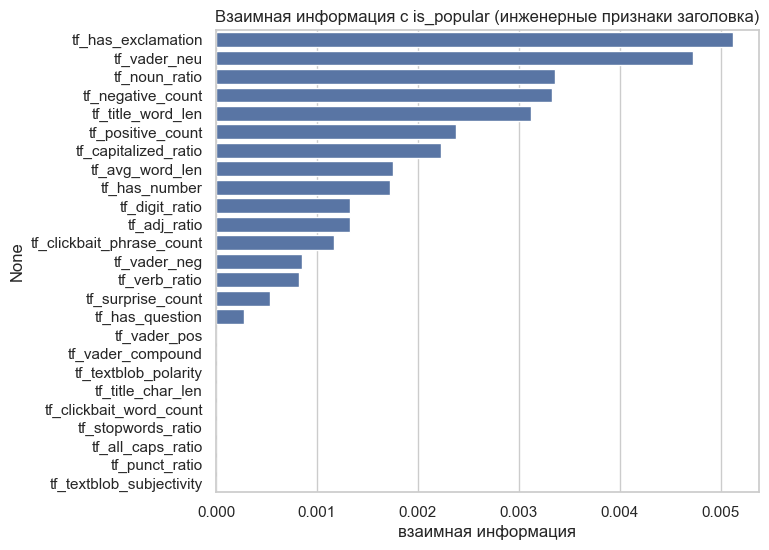

tf_has_exclamation      0.005117
tf_vader_neu            0.004725
tf_noun_ratio           0.003361
tf_negative_count       0.003328
tf_title_word_len       0.003121
tf_positive_count       0.002375
tf_capitalized_ratio    0.002225
tf_avg_word_len         0.001757
tf_has_number           0.001719
tf_digit_ratio          0.001332
dtype: float64

In [5]:
mi = mutual_info_classif(df[tf_cols].to_numpy(), y, random_state=42)
mi_ser = pd.Series(mi, index=tf_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=mi_ser.values, y=mi_ser.index, ax=ax, orient='h')
ax.set_title('Взаимная информация с is_popular (инженерные признаки заголовка)')
ax.set_xlabel('взаимная информация')
plt.savefig(REPORT_IMAGES_DIR / '03_feature_mi.png', bbox_inches='tight')
plt.show()
mi_ser.head(10)

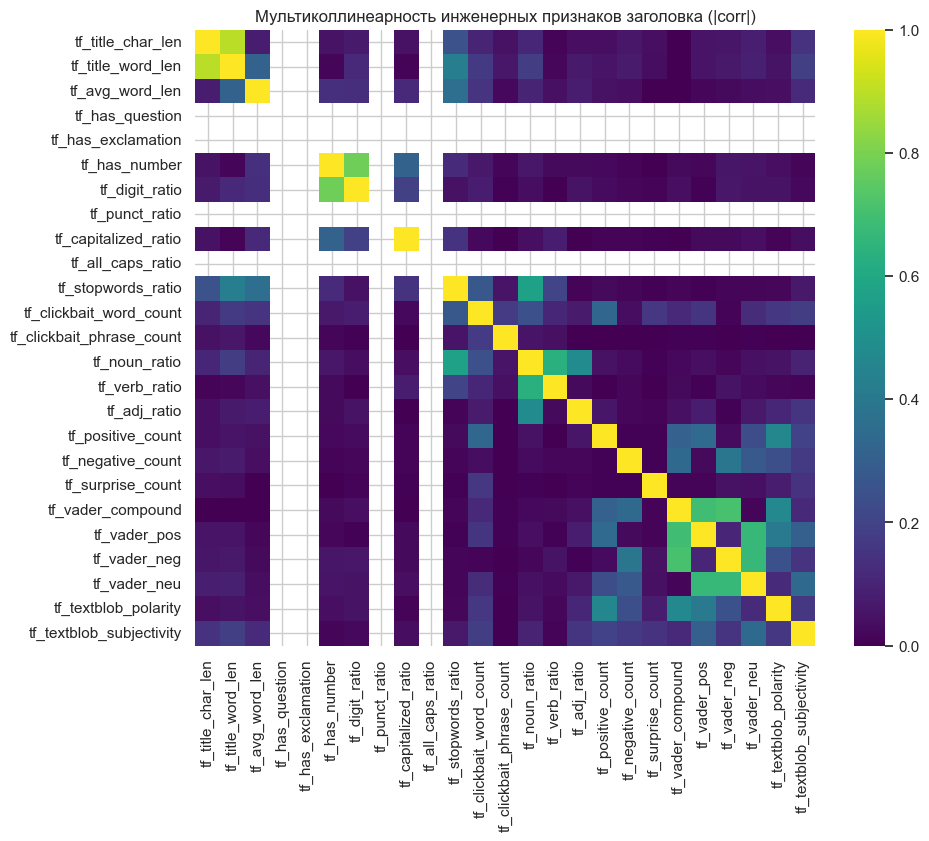

Top-5 feature pairs with strongest absolute correlation:
tf_title_char_len  tf_title_word_len    0.897
tf_has_number      tf_digit_ratio       0.781
tf_vader_compound  tf_vader_neg         0.711
                   tf_vader_pos         0.694
tf_vader_neg       tf_vader_neu         0.670
dtype: float64


In [6]:
corr_mat = df[tf_cols].corr().abs()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('Мультиколлинеарность инженерных признаков заголовка (|corr|)')
plt.savefig(REPORT_IMAGES_DIR / '03_feature_multicollinearity.png', bbox_inches='tight')
plt.show()

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
high = corr_mat.where(mask).stack().sort_values(ascending=False).head(5)
print('Top-5 feature pairs with strongest absolute correlation:')
print(high.round(3))

In [7]:
for col in ['tf_has_question', 'tf_has_number', 'tf_has_exclamation']:
    grouped = df.groupby(col)[TARGET_COL].agg(['median', 'mean', 'count']).round(1)
    print(f'{col} vs shares:')
    print(grouped)
    print()

tf_has_question vs shares:
                 median    mean  count
tf_has_question                       
0.0              1400.0  3395.3  39643

tf_has_number vs shares:
               median    mean  count
tf_has_number                       
0.0            1400.0  3388.8  34325
1.0            1400.0  3437.7   5318

tf_has_exclamation vs shares:
                    median    mean  count
tf_has_exclamation                       
0.0                 1400.0  3395.3  39643



### Выводы (03_features)

* Самые информативные фичи (по MI и \|corr\|): длина заголовка в словах, кликбейт-лексика, доля существительных, VADER-compound. Эмоциональные счётчики слабее, но дают прирост в ансамбле.
* Сильные попарные корреляции: `tf_title_char_len` ↔ `tf_title_word_len`, `tf_vader_pos/neg` ↔ `tf_vader_compound` — это ожидаемо и учтено в отчёте; для линейных моделей используем StandardScaler, для ансамблей мультиколлинеарность не мешает.
* Наличие числа (`tf_has_number`) уверенно сдвигает медиану shares вверх — подтверждение гипотезы о кликбейт-паттерне "5 ways…".